In [1]:
#### Description and imports
import swyft
import pandas as pd
from matplotlib import pyplot as plt

### This specifies the path to your config file
path_to_config = '../examples/config_files/template_powerlaw_sgwb.ini'

### This specifies the path to your logratios file
path_to_logratios = '../sgwb_powerlaw/logratios_sgwb_powerlaw/logratios_R1'

c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\lightning_lite\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
### This cell print the config file
with open(path_to_config) as f:
    FF = f.readlines()

for f in FF:
    print(f[:-1])

[DATA OPTIONS]
n_chunks = 100
n_grid = 1000
sampling_frequency = 1e-4
minimum_frequency = 1e-4
maximum_frequency = 1e-2
transient_store = ../transient_store
transient_store_size = 200_000
p_transient = 0.0

[SGWB INJECTION]
amplitude = -11
tilt = 0

[SGWB PRIORS]
amplitude = -13,-9.
tilt = -2,2

[NOISE INJECTION]
TM = 3.
OMS = 15.

[NOISE PRIORS]
TM = 2.,4.
OMS = 13.,17.

[ZARR PARAMS]
run_id = sgwb_powerlaw
use_zarr = True
sim_schedule = 20_000
chunk_size = 250
run_parallel = False
njobs = 1
store_path = ../sgwb_powerlaw
run_description = Implementation of SGWB analysis for power law templates

[TMNRE]
method = tmnre
one_d = True
marginals = all
num_rounds = 1
infer_only = False
skip_ns = False
resampler = False
noise_targets = data
generate_obs = False
epsilon = 1e-6
logl_th_max = 500.
num_batch_samples = 10
samples_per_slice = 20
num_steps = 4
alpha = 1e-5
obs_path = ../sgwb_powerlaw/observation_sgwb_powerlaw

[SAMPLING]
mcmc_obs_path = ../sgwb_powerlaw/mcmc_observation_sgwb_powerla

In [3]:
### This passes the config to the script to generate observations and executes it
%run generate_observation.py {path_to_config}


             /'{>           Initialising SAQQARA
         ____) (____        --------------------
       //'--;   ;--'\\      Type: Generate Observation
      ///////\_/\\\\\\\     Args: config
             m m            

Fri 24 Apr 22:02:19 | [generate_observation.py] | Reading config file: ../examples/config_files/template_powerlaw_sgwb.ini
Fri 24 Apr 22:02:19 | [generate_observation.py] | Generated observation
Fri 24 Apr 22:02:19 | [generate_observation.py] | Swyft observation Path: ../sgwb_powerlaw/observation_sgwb_powerlaw
Fri 24 Apr 22:02:19 | [generate_observation.py] | MCMC observation Path: ../sgwb_powerlaw/mcmc_observation_sgwb_powerlaw


In [4]:
### This passes the config to the script to generate training set + trains the network 
### If data are not there they will be generated, otherwise will not overwrite
### If infer_only is False will retrain the network, if True will just do the inference
%run tmnre.py {path_to_config}


             /'{>           Initialising SAQQARA
         ____) (____        --------------------
       //'--;   ;--'\\      Type: TMNRE Inference
      ///////\_/\\\\\\\     Args: config
             m m            

Fri 24 Apr 22:02:19 | [tmnre.py] | Reading config file: ../examples/config_files/template_powerlaw_sgwb.ini
Fri 24 Apr 22:02:19 | [tmnre.py] | Observation loaded and saved in ../sgwb_powerlaw/observation_sgwb_powerlaw
Fri 24 Apr 22:02:19 | [tmnre.py] | Initialising zarrstore for round 1
Fri 24 Apr 22:02:19 | [tmnre.py] | Simulating data for round 1
Fri 24 Apr 22:02:19 | [tmnre.py] | WARNING: Running in serial mode


100%|██████████| 250/250 [00:00<00:00, 681.74it/s]
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\trainer\connectors\accelerator_connector.py:441: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
Missing logger folder: ../sgwb_powerlaw/trainer_sgwb_powerlaw_R1\sgwb_powerlaw_R1
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\utilities\model_summary\mod

Fri 24 Apr 22:02:55 | [tmnre.py] | Setting up dataloaders for round 1
Fri 24 Apr 22:02:55 | [tmnre.py] | Setting up trainer for round 1
Fri 24 Apr 22:02:55 | [tmnre.py] | Initialising network for round 1
Fri 24 Apr 22:02:55 | [tmnre.py] | Training network for round 1
Sanity Checking: 0it [00:00, ?it/s]

c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 33: : 624it [01:42,  6.08it/s, loss=-2.85, v_num=0, val_loss=-2.84]Epoch 00034: reducing learning rate of group 0 to 6.0000e-06.
Epoch 34: : 624it [01:48,  5.74it/s, loss=-3.05, v_num=0, val_loss=-2.92]
Fri 24 Apr 23:08:54 | [tmnre.py] | Generate prior samples


100%|██████████| 100000/100000 [00:02<00:00, 40950.75it/s]
Restoring states from the checkpoint path at ../sgwb_powerlaw/trainer_sgwb_powerlaw_R1\epoch=27_val_loss=-2.98_train_loss=-3.13_R1.ckpt
Loaded model weights from checkpoint at ../sgwb_powerlaw/trainer_sgwb_powerlaw_R1\epoch=27_val_loss=-2.98_train_loss=-3.13_R1.ckpt
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, test_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 12 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Fri 24 Apr 23:08:57 | [tmnre.py] | Generate posterior samples
Testing DataLoader 0: : 62it [00:03, 19.60it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           -2.8875656127929688
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Predicting DataLoader 0:   0%|          | 0/49 [00:00<?, ?it/s]

c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\loops\epoch\prediction_epoch_loop.py:173: UserWarning: Lightning couldn't infer the indices fetched for your dataloader.
  warning_cache.warn("Lightning couldn't infer the indices fetched for your dataloader.")


Predicting DataLoader 0: 100%|██████████| 49/49 [00:09<00:00,  5.39it/s]
Fri 24 Apr 23:09:09 | [tmnre.py] | Saving logratios from round 1
Fri 24 Apr 23:09:09 | [tmnre.py] | Update bounds from round 1
Fri 24 Apr 23:09:09 | [tmnre.py] | Completed round 1 in 1:06:50.025635.


In [16]:
### This cell loads the simulator 
%run load_simulator.py {path_to_config}


             /'{>           Initialising SAQQARA
         ____) (____        --------------------
       //'--;   ;--'\\      Type: Load Simulator
      ///////\_/\\\\\\\     
             m m            

Fri 24 Apr 23:10:14 | [load_simulator.py] | Reading config file: ../examples/config_files/template_powerlaw_sgwb.ini


In [17]:
### Loads the logratios from the output
logratios = pd.read_pickle(path_to_logratios)

In [18]:
### Loads the injections and builds a vector
truth = np.append( list(conf['injection']['sgwb'].values()), list(conf['injection']['noise'].values()) )

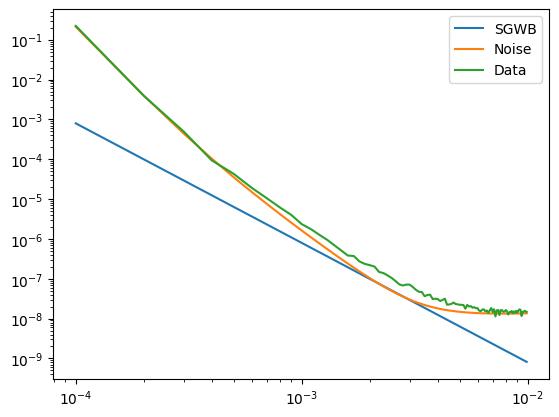

In [19]:
plt.loglog(simulator.f_vec, simulator.sgwb_template(simulator.f_vec, *truth[:2]), label='SGWB')
plt.loglog(simulator.f_vec, simulator.noise_template(simulator.f_vec, *truth[2:]), label='Noise')
plt.loglog(simulator.f_vec, obs['data'], label='Data')
plt.legend(loc=1);

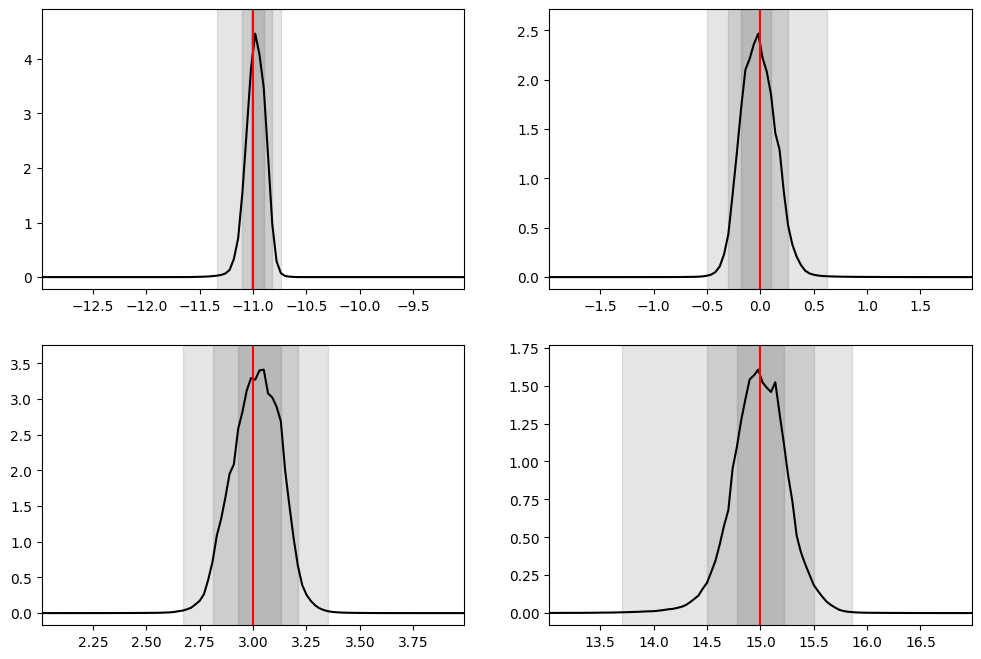

In [20]:
### This cell plots the results
fig = plt.figure(figsize=(12, 8))
for i in range(4):
    ax = plt.subplot(2,2,i+1)
    swyft.plot_1d(logratios, f"z_total[{i}]", ax=ax)
    ax.axvline(truth[i], color='red')

# Let's generate a new injection and test that everything works well

In [21]:
### This cell loads the simulator 
%run load_simulator.py {path_to_config}


             /'{>           Initialising SAQQARA
         ____) (____        --------------------
       //'--;   ;--'\\      Type: Load Simulator
      ///////\_/\\\\\\\     
             m m            

Fri 24 Apr 23:10:40 | [load_simulator.py] | Reading config file: ../examples/config_files/template_powerlaw_sgwb.ini


In [22]:
### This generates a new injection
new_obs = simulator.sample()

In [23]:
### This cell loads the pretrained network, the last number is an integer specifying the inference rounds 
### larger number leads to a better zoom in around the peak
%run load_network.py {path_to_config} 1


             /'{>           Initialising SAQQARA
         ____) (____        --------------------
       //'--;   ;--'\\      Type: Load Network
      ///////\_/\\\\\\\     Args: config, round
             m m            

Fri 24 Apr 23:10:45 | [load_network.py] | Reading config file: ../examples/config_files/template_powerlaw_sgwb.ini


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:00<00:00, 563.67it/s]
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\pytorch_lightning\trainer\connectors\accelerator_connector.py:441: LightningDeprecationWarning: Setting `Trainer(gpus=1)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=1)` instead.
  rank_zero_deprecation(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\Users\uniqu\.conda\envs\lisa_sbi_clean\lib\site-packages\torch\nn\modules\lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
Restoring states from the checkpoint path at ../sgwb_powerlaw/trainer_sgwb_powerlaw_R1\epoch=27_val_loss=-2.98_train_loss=-3.13_R1.ckpt
Loaded model weights from checkpoint at ../sgwb_power

Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 15.89it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           -2.6995091438293457
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fri 24 Apr 23:10:46 | [load_network.py] | Loaded network from checkpoint: ../sgwb_powerlaw/trainer_sgwb_powerlaw_R1\epoch=27_val_loss=-2.98_train_loss=-3.13_R1.ckpt


In [24]:
### This computes the logratios for the new injection point
new_logratios = trainer.infer(network, new_obs, prior_samples.get_dataloader(batch_size=2048))

Predicting: 0it [00:00, ?it/s]

Predicting DataLoader 0: 100%|██████████| 49/49 [00:11<00:00,  4.12it/s]


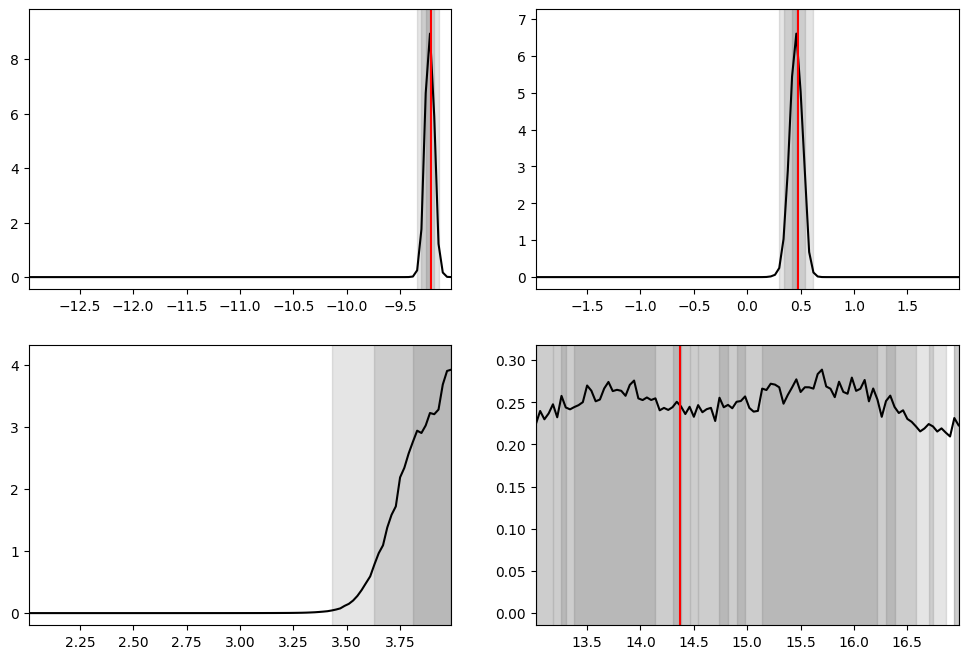

In [25]:
### This cell plots the results
fig = plt.figure(figsize=(12, 8))
for i in range(4):
    ax = plt.subplot(2,2,i+1)
    swyft.plot_1d(new_logratios, f"z_total[{i}]", ax=ax)
    ax.axvline(new_obs['z_total'][i], color='red')

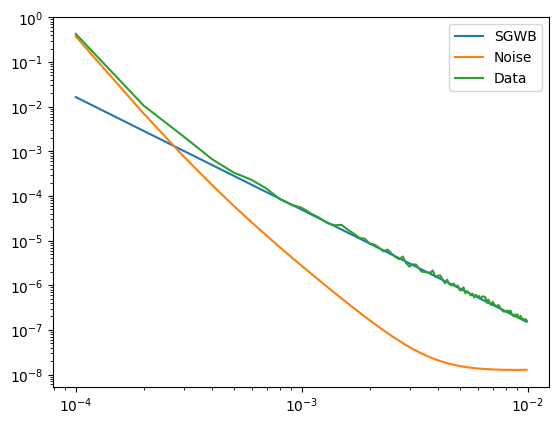

In [26]:
plt.loglog(simulator.f_vec, new_obs['temp_sgwb'], label='SGWB')
plt.loglog(simulator.f_vec, new_obs['temp_noise'], label='Noise')
plt.loglog(simulator.f_vec, new_obs['data'], label='Data')
plt.legend(loc=1);